# S03 — Independent catalogue validation with InfraPy Bartlett beamforming

This supplementary notebook uses the standard frequency-domain Bartlett
beamformer in **LANL InfraPy** to provide an implementation-independent check
of the Falcon 9 infrasound catalogue and of the back-azimuth and trace-velocity
estimates obtained with the project workflow.

The notebook answers two distinct questions:

1. **Event-centred validation:** when a window is centred on each of the 153
   manually associated events, does InfraPy recover coherent energy from the
   direction of SLC-40 at a physically plausible trace velocity?
2. **Blind continuous validation:** when the waveform is scanned without using
   manual event times, how many InfraPy detections match the catalogue, and are
   there credible unmatched detections?

The first analysis is fast enough for routine use but is *not* an independent
test of the event count because the windows are selected from the manual
catalogue. The second is the independent event-detection test and is therefore
the appropriate analysis for statements about catalogue completeness.

Official resources:

- <https://github.com/LANL-Seismoacoustics/infrapy>
- <https://infrapy.readthedocs.io/en/latest/beamforming.html>
- <https://infrapy.readthedocs.io/en/latest/algorithms.html>

## Important implementation choices

- The ObsPy `Stream` is passed directly to InfraPy; no intermediate MiniSEED
  export is required.
- Channel codes and coordinates are read from Notebook 02 products rather than
  hard-coded.
- InfraPy's lower-level Bartlett API is used so that beam-window centre times
  retain sub-second precision. The current convenience `run_fk` implementation
  converts window offsets to integer seconds.
- The primary analysis uses all three pressure sensors. A two-sensor DD2–DD3
  pair can test coherence for a *specified* direction, but two sensors cannot
  independently resolve both back azimuth and trace velocity.
- A short source distance reduces the importance of long-range atmospheric
  ducting, but it does not justify assuming that reflections or multipath are
  impossible.
- Trace velocity is not necessarily identical to the thermodynamic sound
  speed. The meteorological value is retained as an external reference, not as
  a constraint on the Bartlett search.

The Google-AI example command `infrapy run beamform` is not the current official
InfraPy CLI. The documented command family is `infrapy run_fk`, `run_fd`, and
`run_fkd`. This notebook uses the Python API because it avoids file conversion,
makes provenance explicit, and preserves the timing needed here.

In [1]:
from __future__ import annotations

import importlib.metadata
import json
import platform
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from obspy import UTCDateTime, read
from scipy.signal import find_peaks


# Locate the repository whether the kernel starts in the project root or notebooks/.
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = (
    CURRENT_DIR.parent
    if CURRENT_DIR.name == "notebooks"
    else CURRENT_DIR
)
if not (PROJECT_ROOT / "modules" / "project_config.py").exists():
    raise FileNotFoundError(
        "Start this notebook in 08_fireball_paper/ or its notebooks/ directory."
    )
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from modules import project_config as config

pd.set_option("display.max_columns", 100)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})

print("Project root:", PROJECT_ROOT)
print("Data directory:", config.DATA_DIR)

Project root: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper
Data directory: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data


## InfraPy installation and provenance

InfraPy is intentionally not installed by this notebook. The official project
currently recommends cloning the LANL repository and creating its supplied
Conda environment:

```bash
git clone https://github.com/LANL-Seismoacoustics/infrapy.git
cd infrapy
conda env create -f infrapy_env.yml
conda activate infrapy_env
```

Register that environment as a Jupyter kernel if needed. Installing only the
top-level package into the existing analysis environment can omit dependencies
such as Pisces, so the official environment file is the safer reproducible
route.

In [2]:
try:
    import infrapy
    from infrapy.detection import beamforming_new as infrapy_bf
except ImportError as exc:
    raise ImportError(
        "InfraPy is unavailable in this kernel. Install it from the official "
        "LANL repository using infrapy_env.yml, activate that environment, "
        "and restart the notebook with its Jupyter kernel."
    ) from exc

try:
    INFRAPY_VERSION = importlib.metadata.version("infrapy")
except importlib.metadata.PackageNotFoundError:
    INFRAPY_VERSION = "source checkout / version unavailable"

INFRAPY_MODULE_FILE = Path(infrapy.__file__).resolve()
print("InfraPy version:", INFRAPY_VERSION)
print("InfraPy module:", INFRAPY_MODULE_FILE)

InfraPy version: 0.4.1.0
InfraPy module: /Users/thompsong/Developer/infrapy/infrapy/__init__.py


## 1. Inputs and channel/geometry reconciliation

In [3]:
ANALYSIS_CONFIG_FILE = config.OUTPUT_DIR / "02_analysis_configuration.json"
FINAL_CATALOGUE_FILE = config.OUTPUT_DIR / "04_final_153_event_catalogue.csv"
BASELINE_MSEED_FILE = (
    config.DERIVED_DIR
    / "bchh_corrected_moving_median_baseline_removed.mseed"
)
BASELINE_PICKLE_FILE = (
    config.DERIVED_DIR
    / "bchh_corrected_moving_median_baseline_removed.pkl"
)
OUTPUT_DIRECTORY = config.OUTPUT_DIR / "S03_infrapy_bartlett_validation_cont"
FIGURE_DIRECTORY = config.FIGURE_DIR / "S03_infrapy_bartlett_validation_cont"

for required in (
    ANALYSIS_CONFIG_FILE,
    FINAL_CATALOGUE_FILE,
):
    if not required.exists():
        raise FileNotFoundError(required)

analysis_config = json.loads(ANALYSIS_CONFIG_FILE.read_text())
geometry_file = Path(analysis_config["geometry_file"]).expanduser()
if not geometry_file.exists():
    fallback = config.OUTPUT_DIR / "02_bchh_geometry.csv"
    if not fallback.exists():
        raise FileNotFoundError(geometry_file)
    geometry_file = fallback

catalogue = pd.read_csv(FINAL_CATALOGUE_FILE)
geometry = pd.read_csv(geometry_file)

# MiniSEED is deliberately preferred over ObsPy PICKLE here. The baseline
# product was serialized under the project's Python 3.12 environment, whereas
# the official InfraPy environment currently uses Python 3.9. Python pickle is
# not a stable cross-version interchange format and can raise UnpicklingError.
if BASELINE_MSEED_FILE.exists():
    BASELINE_STREAM_FILE = BASELINE_MSEED_FILE
    full_stream = read(str(BASELINE_STREAM_FILE), format="MSEED")
elif BASELINE_PICKLE_FILE.exists():
    BASELINE_STREAM_FILE = BASELINE_PICKLE_FILE
    try:
        full_stream = read(str(BASELINE_STREAM_FILE), format="PICKLE")
    except Exception as exc:
        raise RuntimeError(
            "The baseline PICKLE is incompatible with this Python/ObsPy "
            "environment. Re-run Notebook 06 to write the portable MiniSEED "
            f"product: {BASELINE_MSEED_FILE}"
        ) from exc
else:
    raise FileNotFoundError(BASELINE_MSEED_FILE)

stream_channels = [tr.stats.channel for tr in full_stream]
configured_pressure_channels = analysis_config.get("pressure_channels", [])
pressure_channels = [
    channel
    for channel in configured_pressure_channels
    if channel in stream_channels
]
if not pressure_channels:
    # Unit-based fallback for products created before pressure_channels was saved.
    pressure_channels = [
        tr.stats.channel
        for tr in full_stream
        if str(getattr(tr.stats, "units", "")).lower() in {"pa", "pascal", "pascals"}
    ]
pressure_channels = list(dict.fromkeys(pressure_channels))

if len(pressure_channels) != 3:
    raise ValueError(
        "Bartlett validation expects exactly three pressure channels; found "
        f"{pressure_channels}."
    )

# Preserve the configured order in both the Stream and coordinate matrix.
pressure_stream = full_stream.__class__()
for channel in pressure_channels:
    matches = full_stream.select(channel=channel)
    if len(matches) != 1:
        raise ValueError(f"Expected one trace for {channel}; found {len(matches)}")
    pressure_stream += matches[0].copy()

pressure_geometry = (
    geometry.set_index("channel")
    .loc[pressure_channels]
    .reset_index()
)
latlon = pressure_geometry[["latitude", "longitude"]].to_numpy(float)

sampling_rates = {float(tr.stats.sampling_rate) for tr in pressure_stream}
if len(sampling_rates) != 1:
    raise ValueError(f"Pressure traces have mixed sample rates: {sampling_rates}")
sampling_rate_hz = sampling_rates.pop()

required_catalogue_columns = {
    "final_event_number",
    "reduced_event_epoch_s",
}
missing = required_catalogue_columns.difference(catalogue.columns)
if missing:
    raise KeyError(f"Catalogue is missing columns: {sorted(missing)}")

display(pressure_geometry)
print(pressure_stream)
print("Events:", len(catalogue))
print("Pressure channels:", pressure_channels)
print("Sampling rate:", sampling_rate_hz, "Hz")

,channel,seed_id,network,station,location,latitude,longitude,elevation_m,depth_m,azimuth_deg,dip_deg,sample_rate_hz,original_response_sensitivity,original_response_sensitivity_frequency_hz,original_response_input_units,original_response_output_units,source_name,source_latitude,source_longitude,source_elevation_m,source_to_sensor_distance_m,source_to_sensor_azimuth_deg,sensor_to_source_back_azimuth_deg,empirical_pa_per_count,empirical_count_per_pa,final_response_sensitivity,final_response_sensitivity_frequency_hz,final_response_input_units,final_response_output_units,start_time,end_time,sampling_rate_hz,duration_s,physical_units,baseline_removed_counts,pre_filt_hz,water_level_db,raw_counts_npts,raw_counts_finite_npts,raw_counts_minimum,raw_counts_maximum,raw_counts_peak_absolute,raw_counts_mean,raw_counts_median,raw_counts_standard_deviation,raw_counts_rms,corrected_npts,corrected_finite_npts,corrected_minimum,corrected_maximum,corrected_peak_absolute,corrected_mean,corrected_median,corrected_standard_deviation,corrected_rms,easting_m,northing_m,distance_m,source_to_receiver_azimuth_deg,back_azimuth_to_slc40_deg,sensor,label
0,DD1,1R.BCHH.10.DD1,1R,BCHH,10,28.574222,-80.572417,0.0,0.0,0.0,0.0,250.0,18.4,1.0,Pa,count,SLC40,28.561936,-80.577205,14.032006,1439.963831,18.985737,198.988027,0.1234,8.103728,8.103728,1.0,Pa,count,2016-09-01T13:04:12.080000Z,2016-09-01T13:37:12.080000Z,250.0,1980.0,Pa,-367519.0,"(0.02, 0.05, 80.0, 100.0)",60.0,495001,495001,-380717.0,-357033.0,380717.0,-371928.559264,-372143.0,3224.142858,371942.533590,495001,495001,-253.017930,1349.141452,1349.141452,0.005782,-0.413199,33.066901,33.066901,541816.300901,3.160889e+06,1439.963831,18.985737,198.988027,infraBSU DD1,DD1
1,DD2,1R.BCHH.10.DD2,1R,BCHH,10,28.573881,-80.572296,0.0,0.0,90.0,0.0,250.0,18.4,1.0,Pa,count,SLC40,28.561936,-80.577205,14.032006,1408.338457,19.940904,199.943252,1.4499,0.689703,0.689703,1.0,Pa,count,2016-09-01T13:04:12.080000Z,2016-09-01T13:37:12.080000Z,250.0,1980.0,Pa,1921.0,"(0.02, 0.05, 80.0, 100.0)",60.0,495001,495001,975.0,3000.0,3000.0,1711.141883,1749.0,202.283348,1723.056904,495001,495001,-219.103736,1557.411627,1557.411627,0.004232,-0.042504,7.850680,7.850681,541828.276924,3.160851e+06,1408.338457,19.940904,199.943252,infraBSU DD2,DD2
2,DD3,1R.BCHH.10.DD3,1R,BCHH,10,28.574006,-80.572560,0.0,0.0,0.0,0.0,250.0,18.4,1.0,Pa,count,SLC40,28.561936,-80.577205,14.032006,1412.854330,18.761692,198.763913,0.1000,10.000000,10.000000,1.0,Pa,count,2016-09-01T13:04:12.080000Z,2016-09-01T13:37:12.080000Z,250.0,1980.0,Pa,23215.0,"(0.02, 0.05, 80.0, 100.0)",60.0,495001,495001,16027.0,37698.0,37698.0,21365.644591,21646.0,1738.062593,21436.222390,495001,495001,-222.554264,1434.860925,1434.860925,0.002331,1.222732,13.326245,13.326245,541802.343163,3.160865e+06,1412.854330,18.761692,198.763913,infraBSU DD3,DD3


3 Trace(s) in Stream:
1R.BCHH.10.DD1 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DD2 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DD3 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
Events: 153
Pressure channels: ['DD1', 'DD2', 'DD3']
Sampling rate: 250.0 Hz


In [4]:
# Verify that InfraPy constructs geometry consistent with the surveyed array.
x_all, t_all, t0_all, infrapy_geometry_m = infrapy_bf.stream_to_array_data(
    pressure_stream,
    latlon=latlon,
)

geometry_check = pressure_geometry[["channel", "latitude", "longitude"]].copy()
geometry_check["infrapy_east_offset_m"] = infrapy_geometry_m[:, 0]
geometry_check["infrapy_north_offset_m"] = infrapy_geometry_m[:, 1]
display(geometry_check)

if not np.all(np.isfinite(x_all)):
    raise ValueError("The common pressure array contains non-finite samples.")

,channel,latitude,longitude,infrapy_east_offset_m,infrapy_north_offset_m
0,DD1,28.574222,-80.572417,0.000000,-0.000000
1,DD2,28.573881,-80.572296,11.823639,-37.852953
2,DD3,28.574006,-80.572560,-14.021757,-23.925793


## 2. Analysis controls

`RUN_MODE` determines what is tested:

- `"event_validation"` (default): one Bartlett window per catalogue event plus
  equally many windows from the pre-event background. This validates direction,
  trace velocity, and empirical signal strength efficiently, but does not test
  whether the catalogue contains every event.
- `"continuous_smoke"`: a short blind continuous scan around the beginning of
  the sequence, useful for checking installation and runtime.
- `"continuous_full"`: a blind scan from the pre-event background through the
  final catalogue event. This is the run required to assess catalogue recovery,
  false detections, and completeness.

The primary 0.5-s window has 2-Hz Fourier-bin spacing. Consequently, the
suggested 0.5–5 Hz band contains too few independent bins for this transient
analysis. The adopted 2–20 Hz band is a starting point, not an immutable
choice. Sensitivity tests below should be run before publication.

In [5]:
RUN_MODE = "event_validation"  # event_validation | continuous_smoke | continuous_full
RUN_MODE = "continuous_full"
METHOD = "bartlett"
FREQ_MIN_HZ = 2.0
FREQ_MAX_HZ = 20.0
WINDOW_LENGTH_S = 0.50
WINDOW_STEP_S = 0.10

BACK_AZIMUTH_VALUES_DEG = np.arange(170.0, 230.0 + 0.5, 0.5)
TRACE_VELOCITY_VALUES_MPS = np.arange(280.0, 440.0 + 2.0, 2.0)

# A blind continuous scan evaluates many more windows. Use a coarser screening
# grid; event-centred/follow-up estimates retain the finer grid above.
CONTINUOUS_BACK_AZIMUTH_VALUES_DEG = np.arange(170.0, 230.0 + 1.0, 1.0)
CONTINUOUS_TRACE_VELOCITY_VALUES_MPS = np.arange(280.0, 440.0 + 5.0, 5.0)

# Blind detections must persist across at least this many consecutive windows.
MIN_DETECTION_WINDOWS = 2
MAX_BACK_AZIMUTH_STD_95_DEG = 15.0
BACKGROUND_F_QUANTILE = 0.995
MATCH_TOLERANCE_S = max(WINDOW_LENGTH_S / 2.0, WINDOW_STEP_S)
BLIND_PEAK_MINIMUM_SEPARATION_S = 0.10
BLIND_PEAK_MINIMUM_PROMINENCE_MAD = 2.0

# Smoke scan interval relative to the first reduced catalogue time.
SMOKE_PRE_EVENT_S = 2.0
SMOKE_DURATION_S = 20.0

# Guard against inadvertently starting a very expensive full scan.
CONFIRM_FULL_CONTINUOUS_RUN = False
CONFIRM_FULL_CONTINUOUS_RUN = True

EXPECTED_BACK_AZIMUTH_DEG = float(
    analysis_config["array_reference"]["back_azimuth_to_slc40_deg"]
)
METEOROLOGICAL_EFFECTIVE_SPEED_MPS = 350.98

fft_bin_spacing_hz = 1.0 / WINDOW_LENGTH_S
frequency_bin_count = int(
    np.floor(FREQ_MAX_HZ / fft_bin_spacing_hz)
    - np.ceil(FREQ_MIN_HZ / fft_bin_spacing_hz)
    + 1
)
grid_size = len(BACK_AZIMUTH_VALUES_DEG) * len(TRACE_VELOCITY_VALUES_MPS)
continuous_grid_size = (
    len(CONTINUOUS_BACK_AZIMUTH_VALUES_DEG)
    * len(CONTINUOUS_TRACE_VELOCITY_VALUES_MPS)
)

print(f"FFT-bin spacing: {fft_bin_spacing_hz:.2f} Hz")
print(f"Approximate in-band bins: {frequency_bin_count}")
print(f"Steering models per window: {grid_size:,}")
print(f"Continuous-screening models per window: {continuous_grid_size:,}")
print(f"Expected SLC-40 back azimuth: {EXPECTED_BACK_AZIMUTH_DEG:.2f}°")

FFT-bin spacing: 2.00 Hz
Approximate in-band bins: 10
Steering models per window: 9,801
Continuous-screening models per window: 2,013
Expected SLC-40 back azimuth: 199.44°


## 3. InfraPy Bartlett wrapper with sub-second timing

In [6]:
def circular_difference_deg(values, reference):
    # Signed smallest angular difference, values minus reference.
    values = np.asarray(values, dtype=float)
    return (values - float(reference) + 180.0) % 360.0 - 180.0


def beamform_windows(
    stream,
    latlon_values,
    window_centres_epoch_s,
    *,
    window_length_s,
    freq_band_hz,
    back_azimuth_values_deg,
    trace_velocity_values_mps,
    label,
):
    # Run InfraPy Bartlett beamforming at specified absolute window centres.
    x, t, t0, array_geometry_m = infrapy_bf.stream_to_array_data(
        stream,
        latlon=np.asarray(latlon_values, dtype=float),
    )
    trace_count = x.shape[0]
    t0_epoch_s = pd.Timestamp(t0).timestamp()

    slowness = infrapy_bf.build_slowness(
        np.asarray(back_azimuth_values_deg, dtype=float),
        np.asarray(trace_velocity_values_mps, dtype=float),
    )
    delays = infrapy_bf.compute_delays(array_geometry_m, slowness)

    stream_start_epoch_s = t0_epoch_s + float(t[0])
    stream_end_epoch_s = t0_epoch_s + float(t[-1])
    half_window_s = window_length_s / 2.0
    records = []
    started = time.perf_counter()

    centres = np.asarray(window_centres_epoch_s, dtype=float)
    for index, centre_epoch_s in enumerate(centres, start=1):
        start_epoch_s = centre_epoch_s - half_window_s
        end_epoch_s = centre_epoch_s + half_window_s
        if start_epoch_s < stream_start_epoch_s or end_epoch_s > stream_end_epoch_s:
            continue

        relative_window = [
            start_epoch_s - t0_epoch_s,
            end_epoch_s - t0_epoch_s,
        ]
        X, S, frequencies_hz = infrapy_bf.fft_array_data(
            x,
            t,
            window=relative_window,
        )
        beam_power = infrapy_bf.run(
            X,
            S,
            frequencies_hz,
            array_geometry_m,
            delays,
            list(freq_band_hz),
            method="bartlett",
            pool=None,
            normalize_beam=True,
            ns_covar_inv=None,
        )
        peak = infrapy_bf.find_peaks(
            beam_power,
            np.asarray(back_azimuth_values_deg, dtype=float),
            np.asarray(trace_velocity_values_mps, dtype=float),
            signal_cnt=1,
        )[0]
        coherence = float(np.clip(peak[2], 0.0, 1.0 - np.finfo(float).eps))
        f_stat = coherence / (1.0 - coherence) * (trace_count - 1)

        records.append(
            {
                "analysis_label": label,
                "beam_centre_epoch_s": centre_epoch_s,
                "beam_centre_time": str(UTCDateTime(centre_epoch_s)),
                "back_azimuth_deg": float(peak[0]),
                "trace_velocity_mps": float(peak[1]),
                "bartlett_coherence": coherence,
                "f_stat": float(f_stat),
                "back_azimuth_grid_edge": bool(
                    peak[0]
                    <= back_azimuth_values_deg[0]
                    + np.diff(back_azimuth_values_deg).min() / 2.0
                    or peak[0]
                    >= back_azimuth_values_deg[-1]
                    - np.diff(back_azimuth_values_deg).min() / 2.0
                ),
                "trace_velocity_grid_edge": bool(
                    peak[1]
                    <= trace_velocity_values_mps[0]
                    + np.diff(trace_velocity_values_mps).min() / 2.0
                    or peak[1]
                    >= trace_velocity_values_mps[-1]
                    - np.diff(trace_velocity_values_mps).min() / 2.0
                ),
            }
        )
        if index == 1 or index % 100 == 0 or index == len(centres):
            elapsed = time.perf_counter() - started
            print(f"{label}: {index:,}/{len(centres):,} windows; {elapsed:.1f} s")

    result = pd.DataFrame.from_records(records)
    if result.empty:
        raise RuntimeError(f"No valid windows were analyzed for {label}.")
    result["back_azimuth_error_deg"] = circular_difference_deg(
        result["back_azimuth_deg"], EXPECTED_BACK_AZIMUTH_DEG
    )
    result["trace_velocity_minus_meteorology_mps"] = (
        result["trace_velocity_mps"] - METEOROLOGICAL_EFFECTIVE_SPEED_MPS
    )
    return result

## 4. Define event, background, and continuous windows

In [7]:
event_centres_epoch_s = catalogue["reduced_event_epoch_s"].to_numpy(float)
first_event_epoch_s = float(event_centres_epoch_s.min())
last_event_epoch_s = float(event_centres_epoch_s.max())

common_start_epoch_s = max(
    float(tr.stats.starttime.timestamp) for tr in pressure_stream
)
common_end_epoch_s = min(
    float(tr.stats.endtime.timestamp) for tr in pressure_stream
)

# Use evenly spaced, non-overlapping pre-event windows as an independent null sample.
background_end_epoch_s = first_event_epoch_s - WINDOW_LENGTH_S
background_centres_epoch_s = np.linspace(
    common_start_epoch_s + WINDOW_LENGTH_S / 2.0,
    background_end_epoch_s - WINDOW_LENGTH_S / 2.0,
    num=len(catalogue),
)

if RUN_MODE == "event_validation":
    selected_continuous_centres = np.array([], dtype=float)
elif RUN_MODE == "continuous_smoke":
    scan_start = first_event_epoch_s - SMOKE_PRE_EVENT_S
    scan_end = scan_start + SMOKE_DURATION_S
    selected_continuous_centres = np.arange(
        scan_start + WINDOW_LENGTH_S / 2.0,
        scan_end - WINDOW_LENGTH_S / 2.0 + WINDOW_STEP_S / 2.0,
        WINDOW_STEP_S,
    )
elif RUN_MODE == "continuous_full":
    if not CONFIRM_FULL_CONTINUOUS_RUN:
        raise RuntimeError(
            "Set CONFIRM_FULL_CONTINUOUS_RUN=True after reviewing the estimated "
            "window count and runtime."
        )
    scan_start = common_start_epoch_s
    scan_end = min(common_end_epoch_s, last_event_epoch_s + 2.0)
    selected_continuous_centres = np.arange(
        scan_start + WINDOW_LENGTH_S / 2.0,
        scan_end - WINDOW_LENGTH_S / 2.0 + WINDOW_STEP_S / 2.0,
        WINDOW_STEP_S,
    )
else:
    raise ValueError(f"Unknown RUN_MODE: {RUN_MODE}")

print("Event-centred windows:", len(event_centres_epoch_s))
print("Background windows:", len(background_centres_epoch_s))
print("Continuous windows:", len(selected_continuous_centres))
if len(selected_continuous_centres):
    print(
        "Continuous steering evaluations:",
        f"{len(selected_continuous_centres) * continuous_grid_size:,}",
    )

Event-centred windows: 153
Background windows: 153
Continuous windows: 17839
Continuous steering evaluations: 35,909,907


## 5. Independent waveform-quality measurements

Notebook 04 contains SNR and DD2–DD3 correlation values only for the two
threshold-sensitive events that received targeted review. Consequently, those
columns cannot be used to assess all 153 InfraPy results.

S03 therefore calculates a consistent quality set for every event directly
from the baseline-corrected pressure stream:

- traces are aligned using surveyed source–receiver distances and the
  meteorological effective speed, independently of the Bartlett solution;
- peak SNR is the maximum absolute median-stack signal divided by a robust
  pre-event MAD noise estimate;
- RMS SNR is the median-stack signal RMS divided by its pre-event noise RMS;
- pair correlation is the maximum normalized correlation within a small
  residual-lag search after fixed-geometry alignment.

The correlation pair is selected automatically as the configured reference
sensor and its closest-range pressure companion. This gives DD2–DD3 for BCHH
without hard-coding their names. Local noise windows can contain earlier events
during dense phases, so the output also records neighboring-event gaps and an
isolation flag.

In [8]:
QUALITY_SIGNAL_WINDOW_S = (-0.08, 0.25)
QUALITY_NOISE_WINDOW_S = (-0.50, -0.15)
QUALITY_MAX_RESIDUAL_LAG_S = 0.020

reference_channel = analysis_config["infrasound_reference_channel"]
reference_distance_m = float(
    pressure_geometry.set_index("channel").loc[reference_channel, "distance_m"]
)
fixed_geometry_delays_s = {
    row.channel: (
        float(row.distance_m) - reference_distance_m
    ) / METEOROLOGICAL_EFFECTIVE_SPEED_MPS
    for row in pressure_geometry.itertuples()
}

pair_candidates = pressure_geometry.loc[
    pressure_geometry["channel"].ne(reference_channel)
].copy()
pair_candidates["absolute_range_difference_m"] = (
    pair_candidates["distance_m"] - reference_distance_m
).abs()
quality_pair = [
    reference_channel,
    str(pair_candidates.sort_values("absolute_range_difference_m").iloc[0]["channel"]),
]


def robust_scale(values):
    values = np.asarray(values, dtype=float)
    centre = np.nanmedian(values)
    scale = 1.4826 * np.nanmedian(np.abs(values - centre))
    if not np.isfinite(scale) or scale <= 0.0:
        scale = np.nanstd(values)
    return float(scale)


def sample_trace_at_epochs(trace, epoch_times):
    sample_indices = (
        np.asarray(epoch_times, dtype=float)
        - float(trace.stats.starttime.timestamp)
    ) * float(trace.stats.sampling_rate)
    return np.interp(
        sample_indices,
        np.arange(trace.stats.npts, dtype=float),
        np.asarray(trace.data, dtype=float),
        left=np.nan,
        right=np.nan,
    )


def maximum_normalized_correlation(first, second, maximum_lag_samples):
    first = np.asarray(first, dtype=float)
    second = np.asarray(second, dtype=float)
    records = []
    for lag in range(-maximum_lag_samples, maximum_lag_samples + 1):
        if lag < 0:
            x, y = first[-lag:], second[:lag]
        elif lag > 0:
            x, y = first[:-lag], second[lag:]
        else:
            x, y = first, second
        finite = np.isfinite(x) & np.isfinite(y)
        x, y = x[finite], y[finite]
        if len(x) < 3:
            continue
        x, y = x - np.mean(x), y - np.mean(y)
        denominator = np.linalg.norm(x) * np.linalg.norm(y)
        correlation = np.dot(x, y) / denominator if denominator > 0.0 else np.nan
        records.append((float(correlation), lag))
    finite_records = [record for record in records if np.isfinite(record[0])]
    if not finite_records:
        return np.nan, np.nan
    correlation, lag = max(finite_records, key=lambda record: record[0])
    return correlation, lag / sampling_rate_hz


trace_by_channel = {
    trace.stats.channel: trace
    for trace in pressure_stream
}
sample_interval_s = 1.0 / sampling_rate_hz
signal_relative_s = np.arange(
    QUALITY_SIGNAL_WINDOW_S[0],
    QUALITY_SIGNAL_WINDOW_S[1],
    sample_interval_s,
)
noise_relative_s = np.arange(
    QUALITY_NOISE_WINDOW_S[0],
    QUALITY_NOISE_WINDOW_S[1],
    sample_interval_s,
)
maximum_lag_samples = int(round(QUALITY_MAX_RESIDUAL_LAG_S * sampling_rate_hz))

quality_records = []
for event_number, event_epoch_s in zip(
    catalogue["final_event_number"].astype(int),
    event_centres_epoch_s,
):
    aligned_signal = {}
    aligned_noise = {}
    for channel in pressure_channels:
        delay_s = fixed_geometry_delays_s[channel]
        aligned_signal[channel] = sample_trace_at_epochs(
            trace_by_channel[channel],
            event_epoch_s + signal_relative_s + delay_s,
        )
        aligned_noise[channel] = sample_trace_at_epochs(
            trace_by_channel[channel],
            event_epoch_s + noise_relative_s + delay_s,
        )

    signal_stack = np.nanmedian(
        np.vstack([aligned_signal[channel] for channel in pressure_channels]),
        axis=0,
    )
    noise_stack = np.nanmedian(
        np.vstack([aligned_noise[channel] for channel in pressure_channels]),
        axis=0,
    )
    baseline = np.nanmedian(noise_stack)
    signal_stack = signal_stack - baseline
    noise_stack = noise_stack - baseline
    noise_robust_scale = robust_scale(noise_stack)
    noise_rms = float(np.sqrt(np.nanmean(noise_stack**2)))
    signal_rms = float(np.sqrt(np.nanmean(signal_stack**2)))

    pair_correlation, pair_residual_lag_s = maximum_normalized_correlation(
        aligned_signal[quality_pair[0]],
        aligned_signal[quality_pair[1]],
        maximum_lag_samples,
    )
    quality_records.append(
        {
            "final_event_number": event_number,
            "s03_robust_stack_peak_snr": (
                float(np.nanmax(np.abs(signal_stack))) / noise_robust_scale
                if noise_robust_scale > 0.0 else np.nan
            ),
            "s03_stack_signal_rms_pa": signal_rms,
            "s03_stack_noise_rms_pa": noise_rms,
            "s03_stack_rms_snr": signal_rms / noise_rms if noise_rms > 0.0 else np.nan,
            "s03_pair_channels": "–".join(quality_pair),
            "s03_pair_best_correlation": pair_correlation,
            "s03_pair_residual_lag_s": pair_residual_lag_s,
        }
    )

waveform_quality = pd.DataFrame(quality_records)

sorted_times = np.sort(event_centres_epoch_s)
previous_gaps = np.r_[np.inf, np.diff(sorted_times)]
next_gaps = np.r_[np.diff(sorted_times), np.inf]
gap_table = pd.DataFrame(
    {
        "reduced_event_epoch_s": sorted_times,
        "previous_event_gap_s": previous_gaps,
        "next_event_gap_s": next_gaps,
    }
)
gap_table["s03_quality_window_isolated"] = (
    gap_table["previous_event_gap_s"] >= abs(QUALITY_NOISE_WINDOW_S[0])
) & (
    gap_table["next_event_gap_s"] >= QUALITY_SIGNAL_WINDOW_S[1]
)

print("Quality correlation pair:", "–".join(quality_pair))
display(waveform_quality.describe())

Quality correlation pair: DD2–DD3


,final_event_number,s03_robust_stack_peak_snr,s03_stack_signal_rms_pa,s03_stack_noise_rms_pa,s03_stack_rms_snr,s03_pair_best_correlation,s03_pair_residual_lag_s
count,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000
mean,77.000000,14.328346,18.492324,4.406916,3.667391,0.805211,-0.001673
std,44.311398,17.111265,61.540412,8.756418,3.621349,0.187396,0.002322
min,1.000000,2.037288,1.249565,0.927140,0.522816,0.214737,-0.008000
25%,39.000000,5.494876,3.155109,1.386627,1.651531,0.718361,-0.004000
50%,77.000000,7.859930,5.491451,1.904897,2.231573,0.875550,0.000000
75%,115.000000,16.103719,10.025743,3.268218,4.551155,0.954580,0.000000
max,153.000000,118.527263,447.632457,73.598768,19.608760,0.995207,0.012000


## 6. Run event-centred and background validation

In [9]:
event_beams = beamform_windows(
    pressure_stream,
    latlon,
    event_centres_epoch_s,
    window_length_s=WINDOW_LENGTH_S,
    freq_band_hz=(FREQ_MIN_HZ, FREQ_MAX_HZ),
    back_azimuth_values_deg=BACK_AZIMUTH_VALUES_DEG,
    trace_velocity_values_mps=TRACE_VELOCITY_VALUES_MPS,
    label="catalogue_event",
)
background_beams = beamform_windows(
    pressure_stream,
    latlon,
    background_centres_epoch_s,
    window_length_s=WINDOW_LENGTH_S,
    freq_band_hz=(FREQ_MIN_HZ, FREQ_MAX_HZ),
    back_azimuth_values_deg=BACK_AZIMUTH_VALUES_DEG,
    trace_velocity_values_mps=TRACE_VELOCITY_VALUES_MPS,
    label="pre_event_background",
)

empirical_f_threshold = float(
    background_beams["f_stat"].quantile(BACKGROUND_F_QUANTILE)
)

event_validation = catalogue.merge(
    event_beams,
    left_on="reduced_event_epoch_s",
    right_on="beam_centre_epoch_s",
    how="left",
    validate="one_to_one",
)
event_validation = (
    event_validation
    .merge(
        waveform_quality,
        on="final_event_number",
        how="left",
        validate="one_to_one",
    )
    .merge(
        gap_table,
        on="reduced_event_epoch_s",
        how="left",
        validate="one_to_one",
    )
)
event_validation["above_empirical_background_threshold"] = (
    event_validation["f_stat"] >= empirical_f_threshold
)
event_validation["direction_within_5_deg"] = (
    event_validation["back_azimuth_error_deg"].abs() <= 5.0
)
event_validation["direction_within_10_deg"] = (
    event_validation["back_azimuth_error_deg"].abs() <= 10.0
)
event_validation["f_quality_tier"] = pd.cut(
    event_validation["f_stat"],
    bins=[-np.inf, empirical_f_threshold, 5.0, 10.0, np.inf],
    labels=["below_background", "above_background", "F_ge_5", "F_ge_10"],
    right=False,
)

summary = pd.Series(
    {
        "catalogue_events": len(event_validation),
        "background_f_quantile": BACKGROUND_F_QUANTILE,
        "empirical_f_threshold": empirical_f_threshold,
        "events_above_threshold": int(
            event_validation["above_empirical_background_threshold"].sum()
        ),
        "events_within_5_deg": int(event_validation["direction_within_5_deg"].sum()),
        "events_within_10_deg": int(event_validation["direction_within_10_deg"].sum()),
        "median_back_azimuth_deg": event_validation["back_azimuth_deg"].median(),
        "median_trace_velocity_mps": event_validation["trace_velocity_mps"].median(),
        "median_f_stat": event_validation["f_stat"].median(),
        "back_azimuth_edge_hits": int(event_validation["back_azimuth_grid_edge"].sum()),
        "trace_velocity_edge_hits": int(event_validation["trace_velocity_grid_edge"].sum()),
    },
    name="value",
)
display(summary.to_frame())
display(
    event_validation[
        [
            "final_event_number",
            "reduced_event_time",
            "s03_robust_stack_peak_snr",
            "s03_stack_rms_snr",
            "s03_pair_best_correlation",
            "back_azimuth_deg",
            "back_azimuth_error_deg",
            "trace_velocity_mps",
            "f_stat",
            "above_empirical_background_threshold",
        ]
    ].head(20)
)


def summarize_speed_tier(label, mask):
    selected = event_validation.loc[mask].copy()
    speed = selected["trace_velocity_mps"]
    return {
        "selection": label,
        "event_count": len(selected),
        "median_speed_mps": speed.median(),
        "speed_standard_deviation_mps": speed.std(),
        "speed_p05_mps": speed.quantile(0.05),
        "speed_p95_mps": speed.quantile(0.95),
        "median_abs_back_azimuth_error_deg": selected[
            "back_azimuth_error_deg"
        ].abs().median(),
        "speed_grid_edge_hits": int(selected["trace_velocity_grid_edge"].sum()),
    }


speed_quality_summary = pd.DataFrame(
    [
        summarize_speed_tier("all", np.ones(len(event_validation), dtype=bool)),
        summarize_speed_tier(
            "above_empirical_background",
            event_validation["f_stat"] >= empirical_f_threshold,
        ),
        summarize_speed_tier("F_ge_5", event_validation["f_stat"] >= 5.0),
        summarize_speed_tier("F_ge_10", event_validation["f_stat"] >= 10.0),
        summarize_speed_tier(
            "F_ge_5_and_isolated",
            (event_validation["f_stat"] >= 5.0)
            & event_validation["s03_quality_window_isolated"],
        ),
    ]
)
display(speed_quality_summary)

catalogue_event: 1/153 windows; 0.0 s
catalogue_event: 100/153 windows; 1.8 s
catalogue_event: 153/153 windows; 2.7 s
pre_event_background: 1/153 windows; 0.0 s
pre_event_background: 100/153 windows; 1.8 s
pre_event_background: 153/153 windows; 2.7 s


,value
catalogue_events,153.000000
background_f_quantile,0.995000
empirical_f_threshold,3.022805
events_above_threshold,113.000000
events_within_5_deg,145.000000
events_within_10_deg,151.000000
median_back_azimuth_deg,200.674635
median_trace_velocity_mps,354.604131
median_f_stat,5.035837
back_azimuth_edge_hits,2.000000


,final_event_number,reduced_event_time,s03_robust_stack_peak_snr,s03_stack_rms_snr,s03_pair_best_correlation,back_azimuth_deg,back_azimuth_error_deg,trace_velocity_mps,f_stat,above_empirical_background_threshold
0,1,2016-09-01 13:07:15.927133560+00:00,27.378484,9.484574,0.948681,200.465315,1.027289,369.424961,4.488141,True
1,2,2016-09-01 13:07:16.057133436+00:00,23.590695,10.275813,0.980015,201.610763,2.172737,355.046790,13.519679,True
2,3,2016-09-01 13:07:16.255000114+00:00,7.102597,1.206859,0.971204,201.189102,1.751076,347.546302,8.616138,True
3,4,2016-09-01 13:07:16.447066784+00:00,2.190291,0.838104,0.934742,201.057105,1.619078,347.733731,5.947991,True
4,5,2016-09-01 13:07:16.799566746+00:00,3.110046,0.970274,0.956336,200.220321,0.782295,398.550123,4.677605,True
5,6,2016-09-01 13:07:17.242000103+00:00,4.881015,1.824440,0.979488,202.298438,2.860412,356.517902,10.034957,True
6,7,2016-09-01 13:07:17.634000063+00:00,2.433090,0.761302,0.971295,202.157355,2.719329,350.968910,8.104279,True
7,8,2016-09-01 13:07:17.895133495+00:00,11.507219,2.423968,0.978049,200.908638,1.470612,391.146002,9.937939,True
8,9,2016-09-01 13:07:18.111133575+00:00,10.849010,2.783729,0.982260,201.260317,1.822291,346.690179,11.190800,True
9,10,2016-09-01 13:07:18.389066696+00:00,2.324024,0.522816,0.969432,200.420696,0.982670,428.771105,3.535686,True


,selection,event_count,median_speed_mps,speed_standard_deviation_mps,speed_p05_mps,speed_p95_mps,median_abs_back_azimuth_error_deg,speed_grid_edge_hits
0,all,153,354.604131,30.738694,308.391527,427.953329,1.432204,7
1,above_empirical_background,113,354.417665,20.539055,326.696510,393.775366,1.276841,1
2,F_ge_5,77,355.046790,14.983080,327.061640,381.138452,1.276841,0
3,F_ge_10,42,357.180717,12.101524,345.999350,372.273830,1.436138,0
4,F_ge_5_and_isolated,59,354.417665,13.397589,337.149179,379.731181,1.267467,0


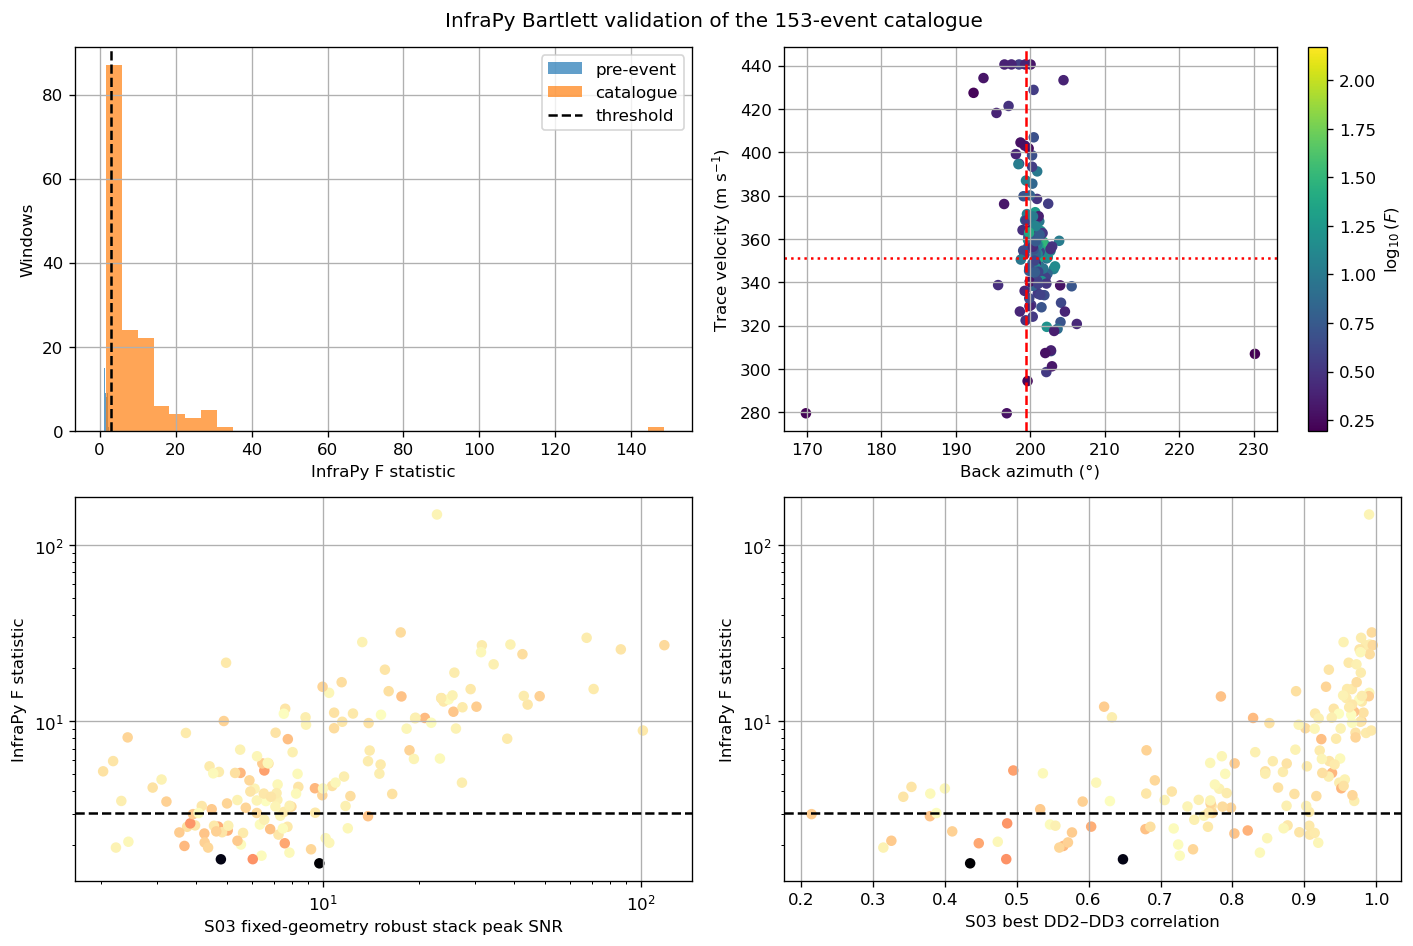

In [10]:
event_validation_figure, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(background_beams["f_stat"], bins=35, alpha=0.7, label="pre-event")
axes[0, 0].hist(event_validation["f_stat"].dropna(), bins=35, alpha=0.7, label="catalogue")
axes[0, 0].axvline(empirical_f_threshold, color="k", ls="--", label="threshold")
axes[0, 0].set_xlabel("InfraPy F statistic")
axes[0, 0].set_ylabel("Windows")
axes[0, 0].legend()

sc = axes[0, 1].scatter(
    event_validation["back_azimuth_deg"],
    event_validation["trace_velocity_mps"],
    c=np.log10(event_validation["f_stat"].clip(lower=1e-6)),
    s=28,
    cmap="viridis",
)
axes[0, 1].axvline(EXPECTED_BACK_AZIMUTH_DEG, color="r", ls="--")
axes[0, 1].axhline(METEOROLOGICAL_EFFECTIVE_SPEED_MPS, color="r", ls=":")
axes[0, 1].set_xlabel("Back azimuth (°)")
axes[0, 1].set_ylabel("Trace velocity (m s$^{-1}$)")
event_validation_figure.colorbar(sc, ax=axes[0, 1], label="$\\log_{10}(F)$")

axes[1, 0].scatter(
    event_validation["s03_robust_stack_peak_snr"],
    event_validation["f_stat"],
    c=event_validation["back_azimuth_error_deg"].abs(),
    cmap="magma_r",
    s=28,
)
axes[1, 0].axhline(empirical_f_threshold, color="k", ls="--")
axes[1, 0].set_xscale("log")
axes[1, 0].set_yscale("log")
axes[1, 0].set_xlabel("S03 fixed-geometry robust stack peak SNR")
axes[1, 0].set_ylabel("InfraPy F statistic")

axes[1, 1].scatter(
    event_validation["s03_pair_best_correlation"],
    event_validation["f_stat"],
    c=event_validation["back_azimuth_error_deg"].abs(),
    cmap="magma_r",
    s=28,
)
axes[1, 1].axhline(empirical_f_threshold, color="k", ls="--")
axes[1, 1].set_yscale("log")
axes[1, 1].set_xlabel(f"S03 best {quality_pair[0]}–{quality_pair[1]} correlation")
axes[1, 1].set_ylabel("InfraPy F statistic")

event_validation_figure.suptitle("InfraPy Bartlett validation of the 153-event catalogue")
event_validation_figure.tight_layout()

## 7. Optional blind continuous scan and InfraPy detection grouping

This section runs only for a continuous mode. It does not use manual event times
to place its analysis windows or set its threshold. The fixed F threshold is
estimated from the independent pre-event background.

Two deliberately different products are retained:

1. InfraPy `run_fd` groups sequential above-threshold windows with consistent
   back azimuth into **activity episodes**. In the dense opening sequence it may
   merge many explosions into one episode and must not be used as the event
   count.
2. Local maxima of the continuous F-statistic series provide **blind peak
   candidates**. These can be matched one-to-one to the manual catalogue, but
   their resolution is limited by the 0.5-s beam window and 0.1-s step.

Because the 0.5-s windows overlap, adjacent detections are not independent. The
minimum sequence, window length, step, frequency band, and threshold quantile
must therefore be reported together and tested for sensitivity.

In [11]:
continuous_beams = pd.DataFrame()
continuous_activity_episodes = pd.DataFrame()
blind_peak_candidates = pd.DataFrame()
manual_recovery = pd.DataFrame()
continuous_figure = None

if len(selected_continuous_centres):
    continuous_beams = beamform_windows(
        pressure_stream,
        latlon,
        selected_continuous_centres,
        window_length_s=WINDOW_LENGTH_S,
        freq_band_hz=(FREQ_MIN_HZ, FREQ_MAX_HZ),
        back_azimuth_values_deg=CONTINUOUS_BACK_AZIMUTH_VALUES_DEG,
        trace_velocity_values_mps=CONTINUOUS_TRACE_VELOCITY_VALUES_MPS,
        label=RUN_MODE,
    )

    times_np = pd.to_datetime(
        continuous_beams["beam_centre_epoch_s"], unit="s", utc=True
    ).to_numpy(dtype="datetime64[ms]")
    peak_matrix = continuous_beams[
        ["back_azimuth_deg", "trace_velocity_mps", "f_stat"]
    ].to_numpy(float)

    # TB product is used by run_fd only for an adaptive threshold. It is still
    # supplied accurately even though this run uses the empirical fixed threshold.
    time_bandwidth_product = max(
        1,
        int(round(WINDOW_LENGTH_S * (FREQ_MAX_HZ - FREQ_MIN_HZ))),
    )
    detections = infrapy_bf.run_fd(
        times_np,
        peak_matrix,
        win_len=max(30.0, 20.0 * WINDOW_LENGTH_S),
        TB_prod=time_bandwidth_product,
        channel_cnt=len(pressure_channels),
        det_p_val=0.99,
        min_seq=MIN_DETECTION_WINDOWS,
        back_az_lim=MAX_BACK_AZIMUTH_STD_95_DEG,
        fixed_thresh=empirical_f_threshold,
        merge_dets=True,
    )

    continuous_activity_episodes = pd.DataFrame(
        detections,
        columns=[
            "detection_time",
            "relative_start_s",
            "relative_end_s",
            "back_azimuth_deg",
            "trace_velocity_mps",
            "f_stat",
        ],
    )
    if not continuous_activity_episodes.empty:
        continuous_activity_episodes["detection_time"] = pd.to_datetime(
            continuous_activity_episodes["detection_time"], utc=True
        )
        continuous_activity_episodes["detection_epoch_s"] = (
            continuous_activity_episodes["detection_time"].astype("int64") / 1e9
        )
        continuous_activity_episodes["back_azimuth_error_deg"] = circular_difference_deg(
            continuous_activity_episodes["back_azimuth_deg"],
            EXPECTED_BACK_AZIMUTH_DEG,
        )

    # Identify local F-statistic maxima separately from the longer run_fd episodes.
    background_f_scale = robust_scale(background_beams["f_stat"])
    minimum_prominence = (
        BLIND_PEAK_MINIMUM_PROMINENCE_MAD * background_f_scale
    )
    minimum_peak_distance_samples = max(
        1,
        int(np.ceil(BLIND_PEAK_MINIMUM_SEPARATION_S / WINDOW_STEP_S)),
    )
    peak_indices, peak_properties = find_peaks(
        continuous_beams["f_stat"].to_numpy(float),
        height=empirical_f_threshold,
        prominence=minimum_prominence,
        distance=minimum_peak_distance_samples,
    )
    blind_peak_candidates = continuous_beams.iloc[peak_indices].copy().reset_index(drop=True)
    blind_peak_candidates.insert(
        0, "blind_peak_number", np.arange(1, len(blind_peak_candidates) + 1)
    )
    if len(blind_peak_candidates):
        blind_peak_candidates["f_prominence"] = peak_properties["prominences"]

    # Greedy one-to-one matching prevents several catalogue events from claiming
    # the same broad F peak. Catalogue times are used only after blind peak finding.
    manual_recovery = catalogue[
        ["final_event_number", "reduced_event_epoch_s", "reduced_event_time"]
    ].copy()
    manual_recovery["blind_peak_number"] = pd.NA
    manual_recovery["peak_minus_event_s"] = np.nan
    manual_recovery["matched"] = False

    candidate_pairs = []
    for event_index, event in manual_recovery.iterrows():
        for peak_index, peak in blind_peak_candidates.iterrows():
            difference_s = float(
                peak["beam_centre_epoch_s"] - event["reduced_event_epoch_s"]
            )
            if abs(difference_s) <= MATCH_TOLERANCE_S:
                candidate_pairs.append(
                    (abs(difference_s), event_index, peak_index, difference_s)
                )
    used_events, used_peaks = set(), set()
    for _, event_index, peak_index, difference_s in sorted(candidate_pairs):
        if event_index in used_events or peak_index in used_peaks:
            continue
        used_events.add(event_index)
        used_peaks.add(peak_index)
        manual_recovery.loc[event_index, "blind_peak_number"] = int(
            blind_peak_candidates.loc[peak_index, "blind_peak_number"]
        )
        manual_recovery.loc[event_index, "peak_minus_event_s"] = difference_s
        manual_recovery.loc[event_index, "matched"] = True

    print("InfraPy activity episodes:", len(continuous_activity_episodes))
    print("Blind local F peaks:", len(blind_peak_candidates))
    print("Catalogue events matched one-to-one:", int(manual_recovery["matched"].sum()))
    print("Unmatched blind peaks:", len(blind_peak_candidates) - len(used_peaks))
else:
    print("Continuous scan skipped in event_validation mode.")

continuous_full: 1/17,839 windows; 0.0 s
continuous_full: 100/17,839 windows; 1.5 s
continuous_full: 200/17,839 windows; 3.1 s
continuous_full: 300/17,839 windows; 4.7 s
continuous_full: 400/17,839 windows; 6.2 s
continuous_full: 500/17,839 windows; 7.8 s
continuous_full: 600/17,839 windows; 9.3 s
continuous_full: 700/17,839 windows; 10.9 s
continuous_full: 800/17,839 windows; 12.5 s
continuous_full: 900/17,839 windows; 14.1 s
continuous_full: 1,000/17,839 windows; 15.6 s
continuous_full: 1,100/17,839 windows; 17.1 s
continuous_full: 1,200/17,839 windows; 18.7 s
continuous_full: 1,300/17,839 windows; 20.2 s
continuous_full: 1,400/17,839 windows; 21.8 s
continuous_full: 1,500/17,839 windows; 23.3 s
continuous_full: 1,600/17,839 windows; 24.9 s
continuous_full: 1,700/17,839 windows; 26.4 s
continuous_full: 1,800/17,839 windows; 28.0 s
continuous_full: 1,900/17,839 windows; 29.5 s
continuous_full: 2,000/17,839 windows; 31.1 s
continuous_full: 2,100/17,839 windows; 32.6 s
continuous_full: 

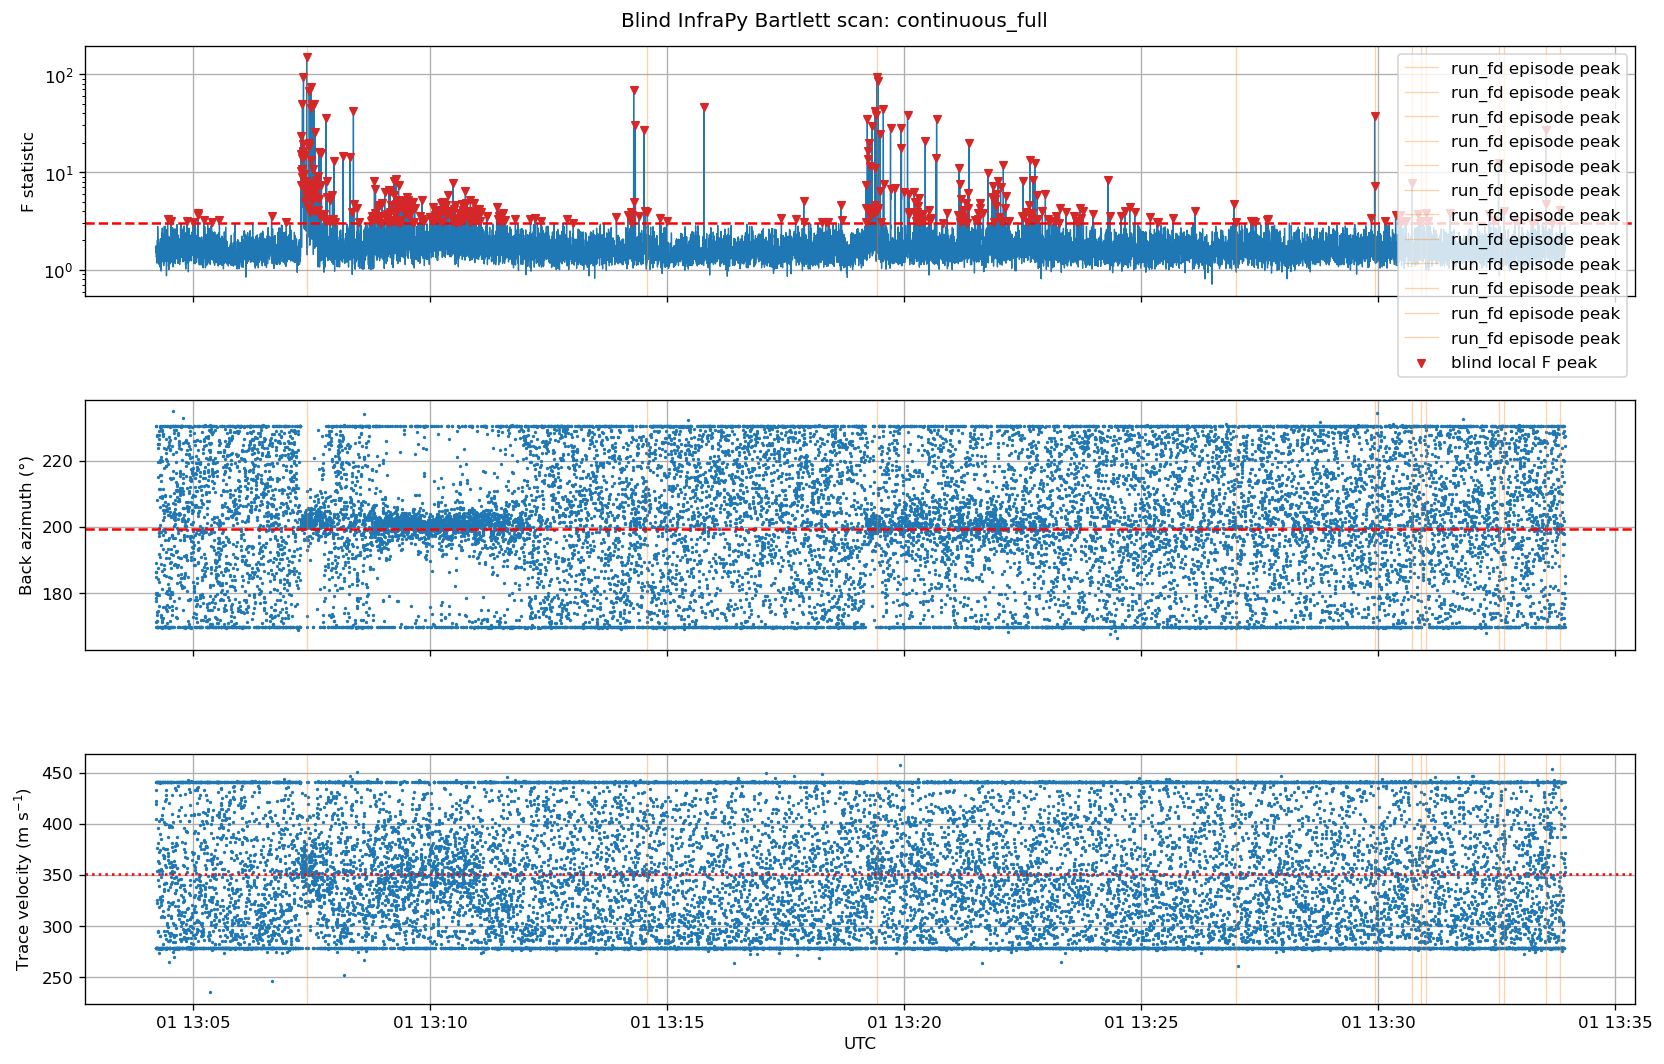

In [12]:
if not continuous_beams.empty:
    continuous_figure, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    times = pd.to_datetime(
        continuous_beams["beam_centre_epoch_s"], unit="s", utc=True
    )
    axes[0].plot(times, continuous_beams["f_stat"], lw=0.8)
    axes[0].axhline(empirical_f_threshold, color="r", ls="--")
    axes[0].set_yscale("log")
    axes[0].set_ylabel("F statistic")
    axes[1].plot(times, continuous_beams["back_azimuth_deg"], ".", ms=2)
    axes[1].axhline(EXPECTED_BACK_AZIMUTH_DEG, color="r", ls="--")
    axes[1].set_ylabel("Back azimuth (°)")
    axes[2].plot(times, continuous_beams["trace_velocity_mps"], ".", ms=2)
    axes[2].axhline(METEOROLOGICAL_EFFECTIVE_SPEED_MPS, color="r", ls=":")
    axes[2].set_ylabel("Trace velocity (m s$^{-1}$)")
    axes[2].set_xlabel("UTC")

    if not continuous_activity_episodes.empty:
        for ax in axes:
            for detection_time in continuous_activity_episodes["detection_time"]:
                ax.axvline(
                    detection_time,
                    color="tab:orange",
                    alpha=0.35,
                    lw=0.8,
                    label="run_fd episode peak" if ax is axes[0] else None,
                )
    if not blind_peak_candidates.empty:
        peak_times = pd.to_datetime(
            blind_peak_candidates["beam_centre_epoch_s"], unit="s", utc=True
        )
        axes[0].scatter(
            peak_times,
            blind_peak_candidates["f_stat"],
            marker="v",
            s=20,
            color="tab:red",
            label="blind local F peak",
            zorder=4,
        )
        axes[0].legend(loc="upper right")
    continuous_figure.suptitle(f"Blind InfraPy Bartlett scan: {RUN_MODE}")
    continuous_figure.tight_layout()

## 8. Parameter sensitivity

For publication, repeat the event-centred and at least one continuous analysis
using physically defensible neighboring parameter sets. Recommended initial
tests are:

| window (s) | band (Hz) | purpose |
|---:|---:|---|
| 0.25 | 4–30 | shortest impulses; reduced low-frequency resolution |
| 0.50 | 2–20 | primary compromise |
| 1.00 | 1–10 | broader arrivals; greater risk of merging nearby events |

Do not choose the final settings solely because they maximize recovery of the
manual catalogue. Report how recovery, false detections, median direction,
trace velocity, and grid-edge hits change. A stable result across nearby
settings is stronger evidence than a single optimized result.

In [13]:
RUN_PARAMETER_SENSITIVITY = False
PARAMETER_SETS = [
    {"name": "short_high", "window_length_s": 0.25, "freq_band_hz": (4.0, 30.0)},
    {"name": "primary", "window_length_s": 0.50, "freq_band_hz": (2.0, 20.0)},
    {"name": "broad_low", "window_length_s": 1.00, "freq_band_hz": (1.0, 10.0)},
]

sensitivity_rows = []
if RUN_PARAMETER_SENSITIVITY:
    for parameter_set in PARAMETER_SETS:
        values = beamform_windows(
            pressure_stream,
            latlon,
            event_centres_epoch_s,
            window_length_s=parameter_set["window_length_s"],
            freq_band_hz=parameter_set["freq_band_hz"],
            back_azimuth_values_deg=BACK_AZIMUTH_VALUES_DEG,
            trace_velocity_values_mps=TRACE_VELOCITY_VALUES_MPS,
            label=parameter_set["name"],
        )
        sensitivity_rows.append(
            {
                **parameter_set,
                "events_analyzed": len(values),
                "median_back_azimuth_deg": values["back_azimuth_deg"].median(),
                "median_abs_back_azimuth_error_deg": values[
                    "back_azimuth_error_deg"
                ].abs().median(),
                "median_trace_velocity_mps": values["trace_velocity_mps"].median(),
                "median_f_stat": values["f_stat"].median(),
                "back_azimuth_edge_hits": int(values["back_azimuth_grid_edge"].sum()),
                "trace_velocity_edge_hits": int(values["trace_velocity_grid_edge"].sum()),
            }
        )

sensitivity_summary = pd.DataFrame(sensitivity_rows)
if not sensitivity_summary.empty:
    display(sensitivity_summary)

## 9. Save auditable products

In [14]:
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)

event_validation_file = OUTPUT_DIRECTORY / "S03_event_centred_bartlett_validation.csv"
background_file = OUTPUT_DIRECTORY / "S03_pre_event_background_bartlett.csv"
metadata_file = OUTPUT_DIRECTORY / "S03_infrapy_validation_metadata.json"
mode_metadata_file = (
    OUTPUT_DIRECTORY / f"S03_{RUN_MODE}_validation_metadata.json"
)

event_validation.to_csv(event_validation_file, index=False)
background_beams.to_csv(background_file, index=False)
waveform_quality.to_csv(
    OUTPUT_DIRECTORY / "S03_event_waveform_quality.csv", index=False
)
speed_quality_summary.to_csv(
    OUTPUT_DIRECTORY / "S03_speed_quality_tier_summary.csv", index=False
)
event_validation_figure.savefig(
    FIGURE_DIRECTORY / "S03_event_centred_bartlett_validation.png",
    dpi=200,
    bbox_inches="tight",
)

if not continuous_beams.empty:
    continuous_beams.to_csv(
        OUTPUT_DIRECTORY / f"S03_{RUN_MODE}_beam_windows.csv", index=False
    )
if continuous_figure is not None:
    continuous_figure.savefig(
        FIGURE_DIRECTORY / f"S03_{RUN_MODE}_beam_results.png",
        dpi=200,
        bbox_inches="tight",
    )
if not continuous_activity_episodes.empty:
    continuous_activity_episodes.to_csv(
        OUTPUT_DIRECTORY / f"S03_{RUN_MODE}_activity_episodes.csv", index=False
    )
if not blind_peak_candidates.empty:
    blind_peak_candidates.to_csv(
        OUTPUT_DIRECTORY / f"S03_{RUN_MODE}_blind_peak_candidates.csv", index=False
    )
if not manual_recovery.empty:
    manual_recovery.to_csv(
        OUTPUT_DIRECTORY / f"S03_{RUN_MODE}_catalogue_recovery.csv", index=False
    )
if not sensitivity_summary.empty:
    sensitivity_summary.to_csv(
        OUTPUT_DIRECTORY / "S03_parameter_sensitivity_summary.csv", index=False
    )

provenance = {
    "schema_version": 1,
    "notebook": "S03_validate_catalogue_with_infrapy_bartlett.ipynb",
    "run_mode": RUN_MODE,
    "infrapy_version": INFRAPY_VERSION,
    "infrapy_module_file": str(INFRAPY_MODULE_FILE),
    "python_version": platform.python_version(),
    "input_files": {
        "analysis_configuration": str(ANALYSIS_CONFIG_FILE),
        "baseline_corrected_stream": str(BASELINE_STREAM_FILE),
        "geometry": str(geometry_file),
        "catalogue": str(FINAL_CATALOGUE_FILE),
    },
    "pressure_channels": pressure_channels,
    "sampling_rate_hz": sampling_rate_hz,
    "method": METHOD,
    "frequency_band_hz": [FREQ_MIN_HZ, FREQ_MAX_HZ],
    "window_length_s": WINDOW_LENGTH_S,
    "window_step_s": WINDOW_STEP_S,
    "back_azimuth_grid_deg": [
        float(BACK_AZIMUTH_VALUES_DEG[0]),
        float(BACK_AZIMUTH_VALUES_DEG[-1]),
        float(np.diff(BACK_AZIMUTH_VALUES_DEG).min()),
    ],
    "trace_velocity_grid_mps": [
        float(TRACE_VELOCITY_VALUES_MPS[0]),
        float(TRACE_VELOCITY_VALUES_MPS[-1]),
        float(np.diff(TRACE_VELOCITY_VALUES_MPS).min()),
    ],
    "continuous_back_azimuth_grid_deg": [
        float(CONTINUOUS_BACK_AZIMUTH_VALUES_DEG[0]),
        float(CONTINUOUS_BACK_AZIMUTH_VALUES_DEG[-1]),
        float(np.diff(CONTINUOUS_BACK_AZIMUTH_VALUES_DEG).min()),
    ],
    "continuous_trace_velocity_grid_mps": [
        float(CONTINUOUS_TRACE_VELOCITY_VALUES_MPS[0]),
        float(CONTINUOUS_TRACE_VELOCITY_VALUES_MPS[-1]),
        float(np.diff(CONTINUOUS_TRACE_VELOCITY_VALUES_MPS).min()),
    ],
    "expected_back_azimuth_deg": EXPECTED_BACK_AZIMUTH_DEG,
    "meteorological_effective_speed_mps": METEOROLOGICAL_EFFECTIVE_SPEED_MPS,
    "background_f_quantile": BACKGROUND_F_QUANTILE,
    "empirical_f_threshold": empirical_f_threshold,
    "minimum_detection_windows": MIN_DETECTION_WINDOWS,
    "catalogue_match_tolerance_s": MATCH_TOLERANCE_S,
    "blind_peak_minimum_separation_s": BLIND_PEAK_MINIMUM_SEPARATION_S,
    "blind_peak_minimum_prominence_mad": BLIND_PEAK_MINIMUM_PROMINENCE_MAD,
}
metadata_file.write_text(json.dumps(provenance, indent=2) + "\n")
mode_metadata_file.write_text(json.dumps(provenance, indent=2) + "\n")

print("Wrote", event_validation_file)
print("Wrote", background_file)
print("Wrote", metadata_file)
print("Wrote", mode_metadata_file)

Wrote /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs/S03_infrapy_bartlett_validation_cont/S03_event_centred_bartlett_validation.csv
Wrote /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs/S03_infrapy_bartlett_validation_cont/S03_pre_event_background_bartlett.csv
Wrote /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs/S03_infrapy_bartlett_validation_cont/S03_infrapy_validation_metadata.json
Wrote /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs/S03_infrapy_bartlett_validation_cont/S03_continuous_full_validation_metadata.json


## Interpretation checklist

Before using this validation in the manuscript:

1. Confirm that strong events do not pile up on a search-grid edge. If they do,
   expand the grid before interpreting medians.
2. Examine low-F windows individually. Weak Bartlett coherence may reflect poor
   SNR, overlapping sources, non-planar wavefronts, or DD1 degradation; it does
   not by itself invalidate a manually associated two-channel event.
3. Compare recovery against the S03 fixed-geometry peak SNR, RMS SNR, and pair
   correlation. Bartlett uses all three channels and should not be treated as
   an independent vote from the two-channel correlation alone.
4. For claims about 153-event completeness, run `continuous_full` and inspect
   both unmatched catalogue events and unmatched InfraPy detections.
5. Repeat nearby window/band/grid choices and report sensitivity rather than
   selecting parameters solely to reproduce 153.
6. Retain the distinction between **trace velocity**, the 350.98 m s$^{-1}$
   meteorological effective speed, and the source-to-array travel speed.

The strongest manuscript use is a concise cross-validation statement supported
by a supplementary recovery table and one figure showing F statistic,
back azimuth, and trace velocity through time. A claim such as “within
$\pm X^\circ$” should be inserted only after the production outputs above have
been generated and reviewed.

### Recommended production sequence

Run the notebook twice from a freshly restarted kernel:

1. `RUN_MODE = "event_validation"` to generate the 153-event direction,
   velocity, Fisher-statistic, waveform-quality, and quality-tier summaries.
2. `RUN_MODE = "continuous_full"` with
   `CONFIRM_FULL_CONTINUOUS_RUN = True` to test catalogue recovery and search
   for unmatched detections without using catalogue times to position windows.

The two runs answer different questions and their mode-specific metadata files
prevent the second run from erasing the provenance of the first.